#MINOR PROJECT 2

#SALES PERFORMANCE ANALYSIS SYSTEM


#PROBLEM STATEMENT

Organizations collect daily sales data but often lack a clear understanding of overall performance,
trends, and category-wise contributions.
This project focuses on analyzing sales data to extract meaningful insights and visualize the given data to identify trends and patterns using Pandas,Matplotlib and Seaborn

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load the dataset

df=pd.read_csv("sales.csv")
df

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,11-19-23,Alicia Davis,Dover,Delaware,East,United States,Home & Furniture,Storage,Storage Rack,1,308.65,308.65,89.57
9996,9997,11-16-24,Mario Nichols,Burlington,Vermont,East,United States,Home & Furniture,Bedding,Tempur-Pedic Mattress,1,973.24,973.24,193.48
9997,9998,02-08-2023,Ruth Bailey,San Diego,California,West,United States,Clothing & Apparel,Women's Wear,Old Navy Dress,1,94.77,94.77,25.72
9998,9999,04-16-23,Mackenzie Skinner,Pittsburgh,Pennsylvania,East,United States,Accessories,Wearable Accessories,Sunglasses,3,226.42,679.26,300.17


In [ ]:
#inspect data structure
#to show number of rows and columns
df.shape

#output=(10000,17)

(10000, 14)

In [ ]:
#to display the column names

df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'City', 'State', 'Region',
       'Country', 'Category', 'Sub_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Revenue', 'Profit'],
      dtype='object')

In [ ]:
#to check the datatypes of the column values

df.dtypes

,0
Order_ID,int64
Order_Date,object
Customer_Name,object
City,object
State,object
Region,object
Country,object
Category,object
Sub_Category,object
Product_Name,object


In [ ]:
#To check the basic statistics of the columns with numerical values

df.describe()

,Order_ID,Quantity,Unit_Price,Revenue,Profit
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.849600,385.353689,715.869528,157.122257
std,2886.89568,1.088714,277.509694,738.705012,150.634933
min,1.00000,1.000000,19.730000,20.300000,4.360000
25%,2500.75000,1.000000,164.827500,230.222500,59.320000
50%,5000.50000,1.000000,308.140000,473.755000,110.405000
75%,7500.25000,2.000000,566.147500,890.640000,203.160000
max,10000.00000,8.000000,1372.890000,7110.960000,1760.890000


In [ ]:
#To display the basic idea or information of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       10000 non-null  int64  
 1   Order_Date     10000 non-null  object 
 2   Customer_Name  10000 non-null  object 
 3   City           10000 non-null  object 
 4   State          10000 non-null  object 
 5   Region         10000 non-null  object 
 6   Country        10000 non-null  object 
 7   Category       10000 non-null  object 
 8   Sub_Category   10000 non-null  object 
 9   Product_Name   10000 non-null  object 
 10  Quantity       10000 non-null  int64  
 11  Unit_Price     10000 non-null  float64
 12  Revenue        10000 non-null  float64
 13  Profit         10000 non-null  float64
dtypes: float64(3), int64(2), object(9)
memory usage: 1.1+ MB


In [ ]:
#to check the total number of missing values

df.isnull().sum()

#no null values

,0
Order_ID,0
Order_Date,0
Customer_Name,0
City,0
State,0
Region,0
Country,0
Category,0
Sub_Category,0
Product_Name,0


In [ ]:
#to check duplicate values

df.duplicated().sum()

#no duplicate values

np.int64(0)

In [ ]:
#we have to analyse monthly expenditure and patterns
#But here the column given is Order_Date which is of type object.
#So this becomes difficult to perfom time based analysis on objects.
#Monthly trends,day-wise analysis won't work
#To solve this problem, we have to convert Order_Date column into a datetime object which allows extracting month,day ,year and to perform time based analysis

df["Order_Date"]=pd.to_datetime(df["Order_Date"])
df["Order_Date"].dtype

dtype('<M8[ns]')

In [ ]:
#creating new columns from date column for analysis

df["Year"]=df["Order_Date"].dt.year
df["Month"]=df["Order_Date"].dt.month
df["Day"]=df["Order_Date"].dt.day


#to check if the new columns have been created
df.head()

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit,Year,Month,Day
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49,2023,8,23
1,2,2024-12-20,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09,2024,12,20
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47,2024,1,29
3,4,2024-11-29,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38,2024,11,29
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46,2023,9,21


In [ ]:
#to analyze total and average expenses

totsales=df["Revenue"].sum()
avgsales=df["Revenue"].mean()

print("The total expense:",totsales)
print("The average expense:",avgsales)

The total expense: 7158695.279999999
The average expense: 715.869528


In [ ]:
#Expenditure analysis based on cities

cityexp=df.groupby('City')['Revenue'].sum()
print(cityexp)

City
Albuquerque        65749.37
Annapolis          97094.75
Atlanta            29590.45
Augusta           132405.19
Aurora             60318.84
                    ...    
Tuscaloosa         33115.43
Virginia Beach     38515.82
Wichita            79485.13
Wilmington        118970.75
Worcester         108804.71
Name: Revenue, Length: 108, dtype: float64


In [ ]:
#City performing the best based on profit

citypro=df.groupby('City')['Profit'].mean().sort_values(ascending=False)
print(citypro)

City
Baton Rouge       216.011887
Sioux Falls       207.038687
New Haven         191.424268
Fort Smith        185.973276
Virginia Beach    184.060213
                     ...    
Tucson            121.480648
Salem             121.443118
New Orleans       121.276364
Kansas City       117.633563
Gulfport          106.756226
Name: Profit, Length: 108, dtype: float64


In [ ]:
#expenditure analysis by state

exp_state=df.groupby('State')['Revenue'].sum()
print(exp_state)

State
Alabama           189705.73
Arizona           349256.96
Arkansas          111717.50
California        353205.25
Colorado          120458.17
Connecticut       249108.87
Delaware          229872.29
Florida           196170.43
Georgia            64754.97
Idaho              71459.62
Illinois          202098.71
Indiana           124043.65
Iowa              123885.33
Kansas            147743.02
Kentucky           80882.20
Louisiana          62952.24
Maine             132405.19
Maryland          203937.72
Massachusetts     226689.02
Michigan          150857.13
Minnesota         130749.67
Mississippi        57984.46
Missouri          110340.80
Montana           116305.25
Nebraska          138338.19
Nevada            134915.25
New Hampshire     264396.10
New Jersey        223942.45
New Mexico        121374.39
New York          208262.56
North Dakota      147905.13
Ohio              199909.59
Oklahoma           82948.44
Oregon             98755.61
Pennsylvania      225061.61
Rhode Island  

In [ ]:
#Category with highest expenditure

category_exp=df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
print(category_exp)

Category
Electronics           2923782.77
Home & Furniture      2385671.95
Clothing & Apparel    1350706.07
Accessories            498534.49
Name: Revenue, dtype: float64


In [ ]:
#Category with highest profit

category_pro=df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_pro)

Category
Home & Furniture      555217.19
Clothing & Apparel    438677.23
Electronics           407690.04
Accessories           169638.11
Name: Profit, dtype: float64


VISUALIZING THE TRENDS

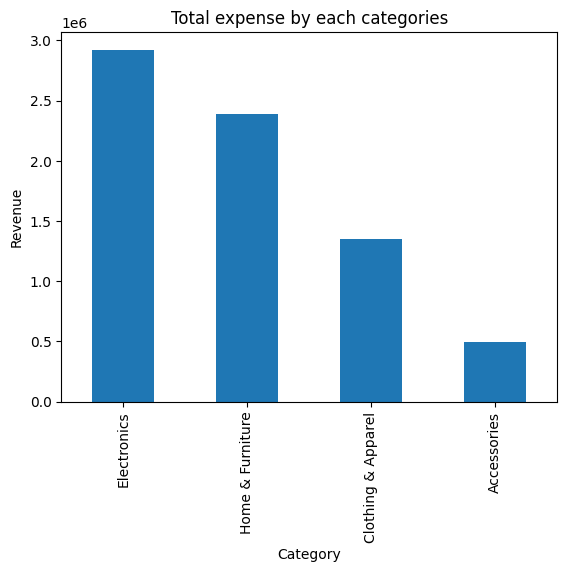

In [ ]:
#Category wise expense analysis
#barchart

category_exp.plot(kind='bar')
plt.title("Total expense by each categories")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

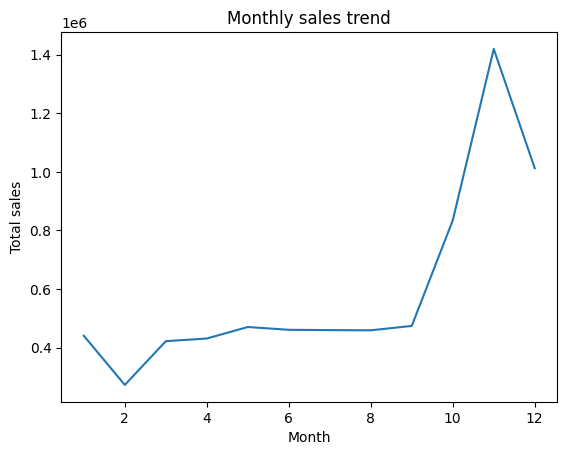

In [ ]:
#Trend analysis over time

#monthly sales trend

mon_sales=df.groupby('Month')['Revenue'].sum()
plt.figure()
mon_sales.plot()
plt.title("Monthly sales trend")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.show()

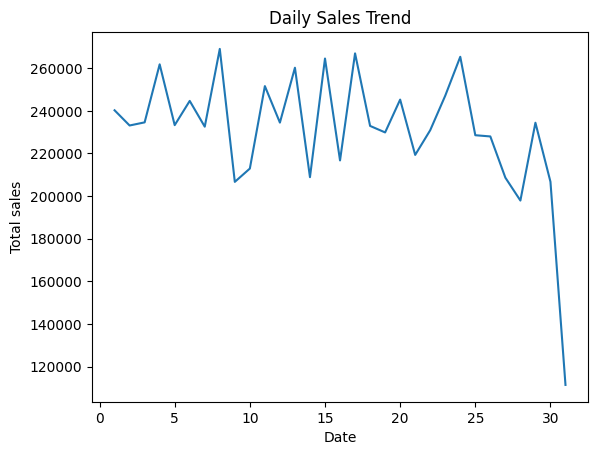

In [ ]:
#daily sales trend

daily_sales=df.groupby('Day')['Revenue'].sum()

plt.figure()
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.show()

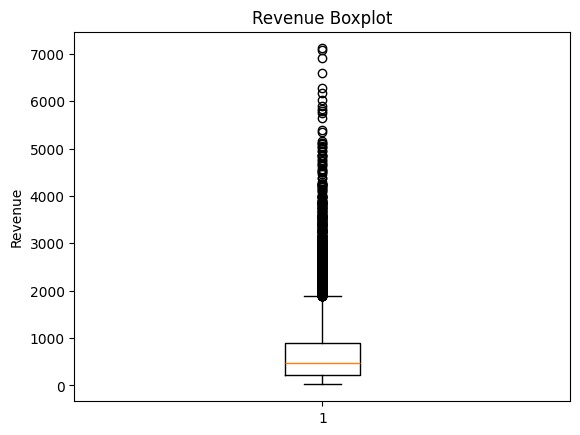

In [ ]:
#Outlier identification
#using boxplot for outlier identification of sales

plt.boxplot(df["Revenue"])
plt.title("Revenue Boxplot")
plt.ylabel("Revenue")
plt.show()

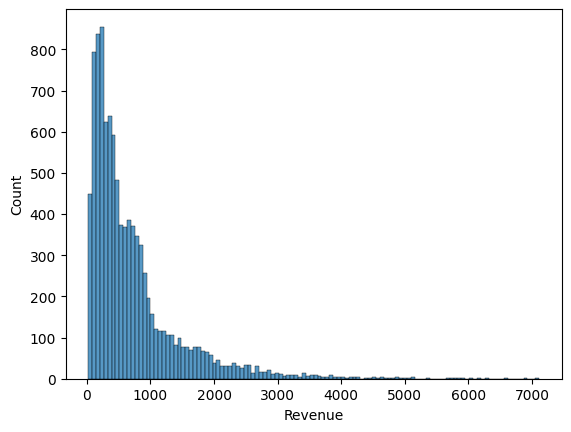

In [ ]:
#outlieridentification using histogram of revenue

sns.histplot(df["Revenue"])
plt.show()

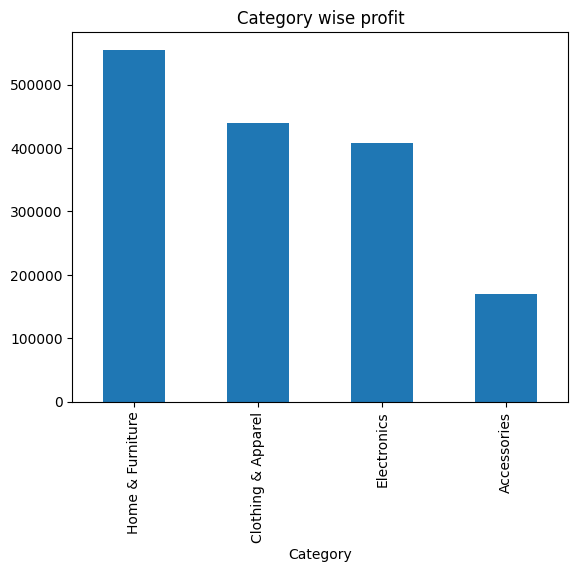

In [ ]:
#Bar chart for category wise profit analysis

category_pro.plot(kind='bar')
plt.title("Category wise profit")
plt.show()

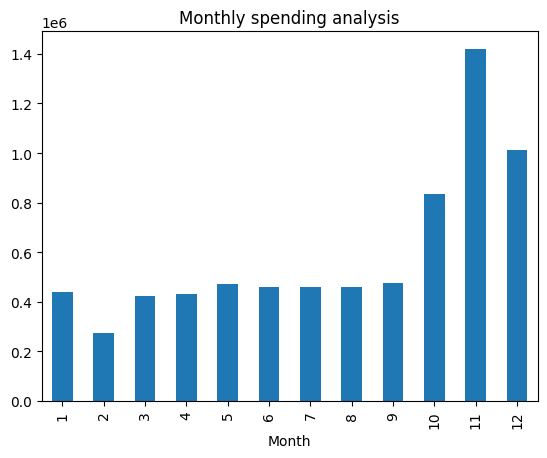

In [ ]:
#Barchart for monthly spending analysis

mon_sales.plot(kind='bar')
plt.title("Monthly spending analysis")
plt.show()

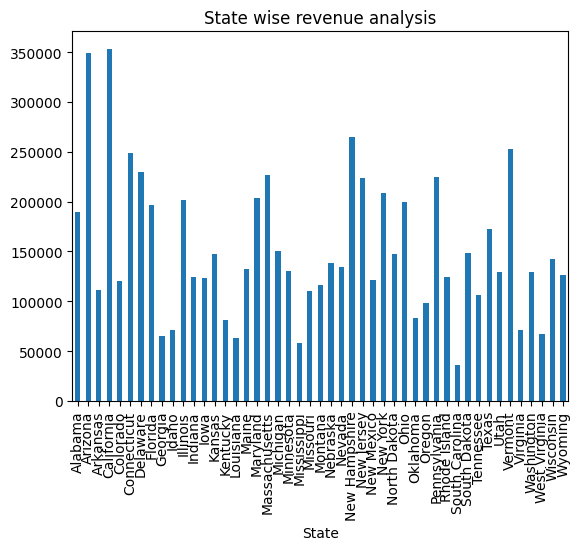

In [ ]:
#state wise revenue distribution analysis by barchart

exp_state.plot(kind='bar')
plt.title("State wise revenue analysis")
plt.show()

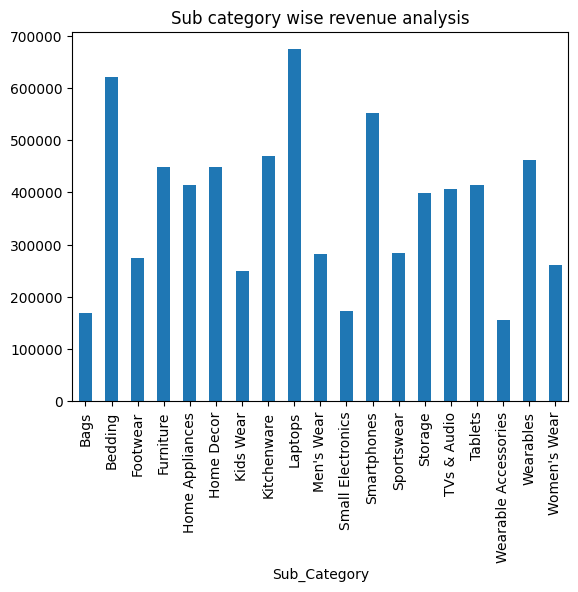

In [ ]:
#sub category trends using barchart

sub_sales=df.groupby('Sub_Category')['Revenue'].sum()
sub_sales.plot(kind='bar')
plt.title("Sub category wise revenue analysis")
plt.show()

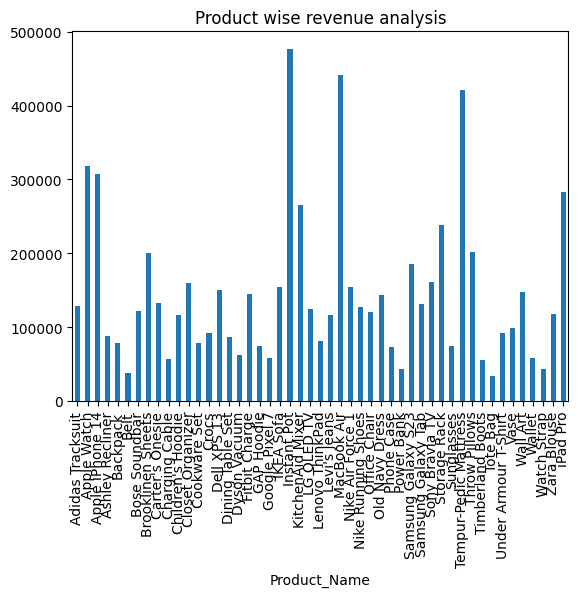

In [ ]:
#product wise trends bar chart

pro_sales=df.groupby('Product_Name')['Revenue'].sum()
pro_sales.plot(kind='bar')
plt.title("Product wise revenue analysis")
plt.show()

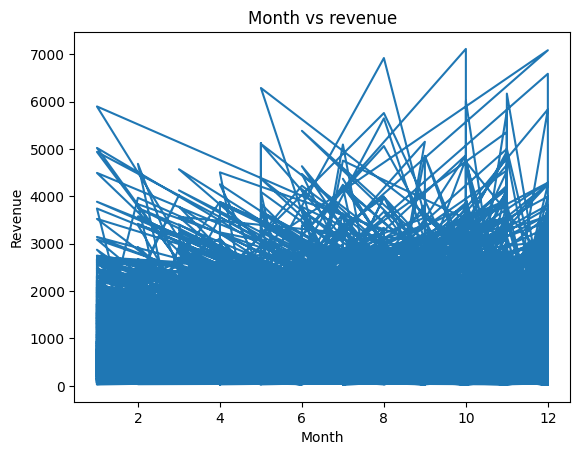

In [ ]:
#line plots for sales trends
#monthly sales trends

plt.plot(df["Month"],df["Revenue"])
plt.title("Month vs revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

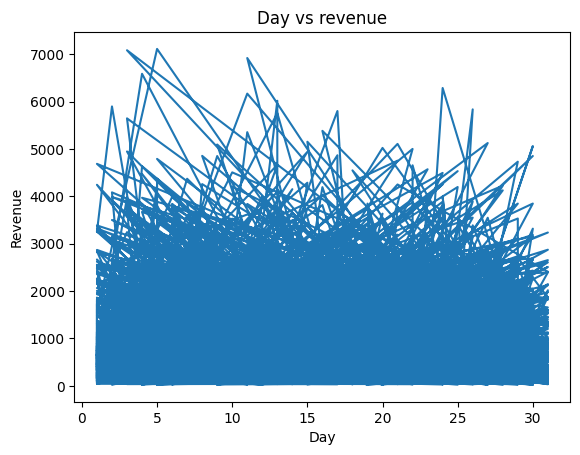

In [ ]:
#daily sales analysis by line plot

plt.plot(df["Day"],df["Revenue"])
plt.title("Day vs revenue")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.show()

#INSIGHTS

The exploratory data analysis revealed several important patterns in the sales dataset

*Revenue is generated the highest in Electronics and least in Accessories

*Profit is generated the highest in Home&Furniture and least in Accessories

*Revenue is generated highest in California and lowest in South Carolina

*The best performing month is November while the least performing month is February

*Taking daily trends, the revenue generated is high during 1st to 3rd weeks and drops significantly during the end of the month

*Revenue is generated highest in the sub category of laptops and least in wearable accessories

*Revenue is generated highest by the product 'Instant Pot' and least by 'Tote Bag'


The analysis revealed key trends in sales performance,including category-wise contributions,customer purchasing patterns and time-based variations. Certain categories drive higher revenue, while others show frequent transactions. These insights can support better business decisions and improve overall performance.